In [1]:
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import warnings
from sklearn.exceptions import ConvergenceWarning

from src.processing import (find_pareto_front, 
                            create_landscape_from_predictions)

from src.visualization import (display_pareto_fronts3, 
                               gerar_gif_evolucao_nsga2, 
                               display_evolution_of_genotypes, 
                               display_fitness_landscape_with_paretos,
                               plot_landscapes_heatmap_dashboard_v2,
                               display_pareto_fronts7)

from src.metrics import (calculate_gamma_convergence_metric, 
                         print_gamma_metric,
                         calculate_fitness_sum_statistics, 
                         print_fitness_sum_statistics,
                         calculate_delta_diversity_metric, 
                         print_delta_metric)

from src.nsgaII import run_my_nsga2
from src.ua_sa_nsgaII import run_my_uasa_nsga2
from src.dr_nsgaII import run_dr_nsga2, create_landscape_for_dr_nsga2
from src.k_rvea_online_runner import run_k_rvea_online
from src.parego_runner import run_parego
from src.prob_moead_runner import run_prob_moead
from src.kta2_runner import run_kta2

from pymoo.core.problem import Problem

/Users/gmello/Documents/python_venvs/mestrado_estatistica/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Parâmetros e algortimos

In [2]:
salva_gifs = False

# Parâmetros NSGA-II
config = {
    # definindo o algoritmo
    'population_size': 100,
    'n_generations': 100,
    'k_tournament': 2,
    'crossover_prob': 0.9,
    'crossover_eta': 15,
    'mutation_prob': 1/6,  # 1/n_var
    'mutation_eta': 20,
    'seed': 42,
    'track_progress': True,
    'utiliza_ds_niching': True,
    'pesos_ds_niching': [1, 1],

    # definindo o problema
    'n_objetivos': 2,
    'fitness_cols': ["fitness1", "fitness2"],
    'maximize': False,
    'n_restricoes': 0,

    # definindo o genótipo
    'tamanho_genotipo': 2,
    'limite_inferior': np.array([-5, -5]),
    'limite_superior': np.array([ 5,  5]),
    'tipo_variavel_genotipo': float
}

config['verbose'] = False
config['mostrar_grafico'] = False

# Cria array de alphas: 1.0 na geração 0, 0.0 na última geração, variação linear
# Alpha controla exploração (1.0) vs convergência (0.0)
n_gens = config['n_generations']
config['alpha_exploration_rank_distance'] = np.linspace(1.0, 0.0, n_gens)

In [3]:
### Seleciona os algoritmos a serem executados
dict_algorithms = {'NSGA2':           False, 
                   'NSGA2_surrogate': True, 
                   'K-RVEA':          True, 
                   'DR-NSGA-II':      True, 
                   'ParEGO':          True, 
                   'Prob-MOEA/D':     True, 
                   'KTA2':            True, 
                   'UA-SA-NSGA2':     True}

In [4]:
def run_algorithms(df_previsao, df_landscape, df_mcmc, problem, dict_algorithms, config):

    suppress = not config.get('verbose', True)
    if suppress:
        warnings.filterwarnings('ignore', category=ConvergenceWarning)

    returns = {}

    ######### NSGA2 - Original
    if dict_algorithms['NSGA2']:
        df_aux = df_previsao.copy()
        df_aux['fitness1'] = df_aux['f1_original']
        df_aux['fitness2'] = df_aux['f2_original']
        
        df_pareto_my, _, _ = run_my_nsga2(config, df_aux)
        df_pareto_my['f1'] = df_pareto_my['f1_original']
        df_pareto_my['f2'] = df_pareto_my['f2_original']

        returns['NSGA2'] = df_pareto_my


    ######### NSGA2 - Surrogate
    if dict_algorithms['NSGA2_surrogate']:
        df_aux = df_previsao.copy()
        df_aux['fitness1'] = df_aux['f1_predicted']
        df_aux['fitness2'] = df_aux['f2_predicted']

        df_pareto_my2, _, _ = run_my_nsga2(config, df_aux)
        df_pareto_my2['f1'] = df_pareto_my2['f1_original']
        df_pareto_my2['f2'] = df_pareto_my2['f2_original']

        returns['NSGA2_surrogate'] = df_pareto_my2


    ######### K-RVEA online (Kriging-assisted with true function evaluations)
    if dict_algorithms['K-RVEA']:
        config_krvea = config.copy()
        config_krvea['FEmax'] = 300
        config_krvea['krvea_wmax'] = 20
        config_krvea['krvea_u'] = 5
        config_krvea['krvea_NI'] = 21  # 11*n_var - 1

        df_pareto_krvea, krvea_info = run_k_rvea_online(problem, config_krvea)

        returns['K-RVEA'] = df_pareto_krvea


    ######### DR-NSGA-II (Dual-Ranking NSGA-II with uncertainty)
    if dict_algorithms['DR-NSGA-II']:
        decision_variables = ['x_1', 'x_2']
        df_landscape_dr = create_landscape_for_dr_nsga2(
            df_previsao=df_previsao,
            df_mcmc=df_mcmc,
            z=1.28,
            decision_variables=decision_variables
        )

        config_dr = config.copy()
        config_dr['adjusted_fitness_cols'] = ['fitness1_adj', 'fitness2_adj']

        df_pareto_dr, _, _ = run_dr_nsga2(config_dr, df_landscape_dr)
        df_pareto_dr['f1'] = df_pareto_dr['f1_original']
        df_pareto_dr['f2'] = df_pareto_dr['f2_original']

        returns['DR-NSGA-II'] = df_pareto_dr


    ######### ParEGO (online - Kriging + Expected Improvement + Tchebycheff scalarization)
    if dict_algorithms['ParEGO']:
        config_parego = config.copy()
        config_parego['FEmax'] = 250
        config_parego['parego_NI'] = 21

        df_pareto_parego, parego_info = run_parego(problem, config_parego)

        returns['ParEGO'] = df_pareto_parego


    ######### Prob-MOEA/D (offline - probabilistic PBI selection with MC sampling)
    if dict_algorithms['Prob-MOEA/D']:
        df_previsao_aux_pmoead = df_previsao.copy()
        df_previsao_aux_pmoead['fitness1'] = df_previsao_aux_pmoead['f1_predicted']
        df_previsao_aux_pmoead['fitness2'] = df_previsao_aux_pmoead['f2_predicted']
        
        config_pmoead = config.copy()
        config_pmoead['prob_moead_samples'] = 50
        config_pmoead['moead_neighborhood'] = 20
        
        df_pareto_pmoead, _, _ = run_prob_moead(config_pmoead, df_previsao_aux_pmoead, df_previsao, df_mcmc)
        df_pareto_pmoead['f1'] = df_pareto_pmoead['f1_original']
        df_pareto_pmoead['f2'] = df_pareto_pmoead['f2_original']

        returns['Prob-MOEA/D'] = df_pareto_pmoead


    ######### KTA2 (online - Two-Archive + adaptive sampling + influential point-insensitive Kriging)
    if dict_algorithms['KTA2']:
        config_kta2 = config.copy()
        config_kta2['FEmax'] = 300
        config_kta2['kta2_archive_size'] = 100
        config_kta2['kta2_eta'] = 5

        df_pareto_kta2, kta2_info = run_kta2(problem, config_kta2)

        returns['KTA2'] = df_pareto_kta2


    ######### UA-SA-NSGA2
    if dict_algorithms['UA-SA-NSGA2']:
        config['utiliza_ds_niching'] = False
        df_pareto_ua_sa, history = run_my_uasa_nsga2(config, df_landscape, save_history=True)
        df_pareto_ua_sa.drop_duplicates(subset=['x_1_landscape', 'x_2_landscape'], inplace=True)
        df_pareto_ua_sa = (df_pareto_ua_sa[['x_1_landscape', 'x_2_landscape', 'f1_original', 'f2_original']].
                                    rename(columns={'x_1_landscape': 'x_1', 
                                                    'x_2_landscape': 'x_2', 
                                                    'f1_original': 'f1', 
                                                    'f2_original': 'f2'
                                        })
        )

        returns['UA-SA-NSGA2'] = df_pareto_ua_sa


    if suppress:
        warnings.filterwarnings('default', category=ConvergenceWarning)

    return returns

# Problems

In [5]:
class MMF1(Problem):
    """
    Implementação matemática EXATA do problema MMF1 (CEC 2019 MMOP).
    Possui duas regiões ótimas globais no espaço de decisão que espelham 
    em x1 = 2, formando uma ponta (descontinuidade da derivada).
    """
    def __init__(self):
        # Limites oficiais do MMF1: x1 em [1, 3], x2 em [-1, 1]
        super().__init__(n_var=2, n_obj=2, xl=np.array([1.0, -1.0]), xu=np.array([3.0, 1.0]))

    def _evaluate(self, X, out, *args, **kwargs):
        x1, x2 = X[:, 0], X[:, 1]
        
        # f1 mapeia [1, 3] para [0, 1] espelhando no 2
        f1 = np.abs(x1 - 2.0)
        
        # A senoide com período 1/3 (6*pi) e deslocamento de fase (pi)
        # que gera a ponta aguda (descontinuidade) em x1 = 2
        senoide = np.sin(6.0 * np.pi * np.abs(x1 - 2.0) + np.pi)
        
        # f2 penaliza qualquer desvio da senoide
        f2 = 1.0 - np.sqrt(f1) + 2.0 * (x2 - senoide)**2
        
        out["F"] = np.column_stack([f1, f2])

In [6]:
class MMF4(Problem):
    """
    Problema MMF4 (Niching Simétrico).
    Forte não-linearidade com 4 conjuntos de Pareto globais no espaço de decisão 
    (formando perfeitamente dois 'M's empilhados, como o logo do McDonald's).
    """
    def __init__(self):
        # Limites: x1 de -1 a 1 | x2 de 0 a 2
        super().__init__(n_var=2, n_obj=2, xl=np.array([-1.0, 0.0]), xu=np.array([1.0, 2.0]))

    def _evaluate(self, X, out, *args, **kwargs):
        x1, x2 = X[:, 0], X[:, 1]
        
        # Equações exatas do MMF4 com a periodicidade corrigida!
        f1 = np.abs(x1)
        
        # O uso do sin(pi * (...)) cria as raízes múltiplas.
        # Raiz 1: x2 = sin(pi*|x1|)       -> O "M" de baixo (0 a 1)
        # Raiz 2: x2 = 1 + sin(pi*|x1|)   -> O "M" de cima (1 a 2)
        f2 = 1.0 - x1**2 + 2.0 * np.sin(np.pi * (x2 - np.sin(np.pi * np.abs(x1))))**2
        
        out["F"] = np.column_stack([f1, f2])

In [7]:
class BBOB_Gallagher_Mock(Problem):
    def __init__(self, n_peaks=101):
        super().__init__(n_var=2, n_obj=2, xl=np.array([-5.0, -5.0]), xu=np.array([5.0, 5.0]))
        self.n_peaks = n_peaks

        np.random.seed(42)

        self.c1 = np.random.uniform(-4.5, 4.5, (n_peaks, 2))
        self.w1 = np.random.uniform(0.1, 2.0, n_peaks)
        self.s1 = np.random.uniform(0.2, 1.0, n_peaks)

        self.c2 = np.random.uniform(-4.5, 4.5, (n_peaks, 2))
        self.w2 = np.random.uniform(0.1, 2.0, n_peaks)
        self.s2 = np.random.uniform(0.2, 1.0, n_peaks)

        # Pre-compute global minimums on a dense grid
        g = np.linspace(-5.0, 5.0, 500)
        X1, X2 = np.meshgrid(g, g)
        X_grid = np.column_stack([X1.ravel(), X2.ravel()])

        f1_raw = np.zeros(len(X_grid))
        f2_raw = np.zeros(len(X_grid))
        for i in range(n_peaks):
            d1 = np.sum((X_grid - self.c1[i])**2, axis=1)
            f1_raw -= self.w1[i] * np.exp(-d1 / (2 * self.s1[i]**2))
            d2 = np.sum((X_grid - self.c2[i])**2, axis=1)
            f2_raw -= self.w2[i] * np.exp(-d2 / (2 * self.s2[i]**2))

        self._f1_global_min = np.min(f1_raw)
        self._f2_global_min = np.min(f2_raw)

    def _evaluate(self, X, out, *args, **kwargs):
        f1 = np.zeros(X.shape[0])
        f2 = np.zeros(X.shape[0])

        for i in range(self.n_peaks):
            dist1 = np.sum((X - self.c1[i])**2, axis=1)
            f1 -= self.w1[i] * np.exp(-dist1 / (2 * self.s1[i]**2))
            dist2 = np.sum((X - self.c2[i])**2, axis=1)
            f2 -= self.w2[i] * np.exp(-dist2 / (2 * self.s2[i]**2))

        f1 = f1 - self._f1_global_min + 0.1
        f2 = f2 - self._f2_global_min + 0.1

        out["F"] = np.column_stack([f1, f2])

In [8]:
# Inicializando os problemas
mmf1   = MMF1()
mmf4   = MMF4()
bbob16 = BBOB_Gallagher_Mock()

# Inputs

In [9]:
df_mmf1_previsao   = pd.read_parquet('data/dataframes/MMF1/df_mmf1_previsao.parquet')
df_mmf4_previsao   = pd.read_parquet('data/dataframes/MMF4/df_mmf4_previsao.parquet')
df_bbob16_previsao = pd.read_parquet('data/dataframes/BBOB16/df_bbob16_previsao.parquet')

df_mmf1   = pd.read_parquet('data/dataframes/MMF1/df_mmf1.parquet')
df_mmf4   = pd.read_parquet('data/dataframes/MMF4/df_mmf4.parquet')
df_bbob16 = pd.read_parquet('data/dataframes/BBOB16/df_bbob16.parquet')

print(df_mmf1_previsao.shape)
print(df_mmf4_previsao.shape)

print(df_bbob16_previsao.shape)
display(df_bbob16_previsao.head())

(999504, 12)
(999504, 12)
(999504, 12)


,x_1,x_2,f1,f2,aux,bin_x1,bin_x2,regiao,f1_original,f2_original,f1_predicted,f2_predicted
0,-5.00000,-5.0,8.572678,5.373520,1,0,0,1,8.666458,5.831612,7.537771,5.432501
1,-4.98999,-5.0,9.817608,6.573840,1,0,0,1,8.664741,5.826446,7.537771,5.432501
2,-4.97998,-5.0,9.266795,6.838362,1,0,0,1,8.663011,5.821131,7.537771,5.432501
3,-4.96997,-5.0,7.802764,6.484634,1,0,0,1,8.661268,5.815663,7.537771,5.432501
4,-4.95996,-5.0,7.860051,6.418849,1,0,0,1,8.659512,5.810039,7.537771,5.432501


In [10]:
df_mcmc_mmf1 = pd.read_parquet('data/dataframes/MMF1/df_mmf1_mcmc.parquet').rename(columns={'index_linha': 'id_simulacao'})
df_mcmc_mmf4 = pd.read_parquet('data/dataframes/MMF4/df_mmf4_mcmc.parquet').rename(columns={'index_linha': 'id_simulacao'})
df_mcmc_bbob16 = pd.read_parquet('data/dataframes/BBOB16/df_bbob16_mcmc.parquet').rename(columns={'index_linha': 'id_simulacao'})

df_mcmc_mmf1.sort_values(['regiao', 'id_simulacao'], inplace=True)
df_mcmc_mmf4.sort_values(['regiao', 'id_simulacao'], inplace=True)
df_mcmc_bbob16.sort_values(['regiao', 'id_simulacao'], inplace=True)

config['n_simulations'] = df_mcmc_mmf1['id_simulacao'].max() + 1
print('n_simulations: ', config['n_simulations'])

print(df_mcmc_mmf1.shape)
print(df_mcmc_mmf4.shape)
print(df_mcmc_bbob16.shape)

df_mcmc_bbob16

n_simulations:  50
(800, 4)
(800, 4)
(800, 4)


,id_simulacao,regiao,erro_f1,erro_f2
0,0,1,-0.940290,-0.004488
1,1,1,0.433447,0.702521
2,2,1,3.275363,1.805439
3,3,1,-1.834218,0.013548
4,4,1,2.837158,2.411158
...,...,...,...,...
795,45,9,0.507084,0.098607
796,46,9,0.148620,1.262025
797,47,9,-0.931560,-0.306874
798,48,9,1.408835,1.301709


# BBOB16

In [11]:
decision_variables = ['x_1', 'x_2']

df_landscape_bbob16 = create_landscape_from_predictions(
    df_previsao=df_bbob16_previsao,
    df_mcmc=df_mcmc_bbob16,
    decision_variables=decision_variables
)

print(df_landscape_bbob16.shape)
df_landscape_bbob16.head()

(999504, 10)


,x_1,x_2,f1,f2,f1_original,f2_original,f1_predicted,f2_predicted,fitness1,fitness2
0,-5.0,-5.00000,8.572678,5.373520,8.666458,5.831612,7.537771,5.432501,"[6.597, 7.971, 10.813, 5.704, 10.375, 11.759, ...","[5.428, 6.135, 7.238, 5.446, 7.844, 7.368, 5.7..."
1,-5.0,-4.98999,7.835912,5.360375,8.663712,5.827599,7.537771,5.432501,"[6.597, 7.971, 10.813, 5.704, 10.375, 11.759, ...","[5.428, 6.135, 7.238, 5.446, 7.844, 7.368, 5.7..."
2,-5.0,-4.97998,10.877759,6.498282,8.660909,5.823506,7.537771,5.432501,"[6.597, 7.971, 10.813, 5.704, 10.375, 11.759, ...","[5.428, 6.135, 7.238, 5.446, 7.844, 7.368, 5.7..."
3,-5.0,-4.96997,8.126557,6.574268,8.658049,5.819332,7.537771,5.432501,"[6.597, 7.971, 10.813, 5.704, 10.375, 11.759, ...","[5.428, 6.135, 7.238, 5.446, 7.844, 7.368, 5.7..."
4,-5.0,-4.95996,7.760877,5.182539,8.655130,5.815076,7.537771,5.432501,"[6.597, 7.971, 10.813, 5.704, 10.375, 11.759, ...","[5.428, 6.135, 7.238, 5.446, 7.844, 7.368, 5.7..."


In [12]:
#returns = run_algorithms(df_bbob16_previsao, df_landscape_bbob16, df_mcmc_bbob16, bbob16, dict_algorithms, config)
#
#df_pareto_my2_bbob16    = returns['NSGA2_surrogate']
#df_pareto_krvea_bbob16  = returns['K-RVEA']
#df_pareto_dr_bbob16     = returns['DR-NSGA-II']
#df_pareto_parego_bbob16 = returns['ParEGO']
#df_pareto_pmoead_bbob16 = returns['Prob-MOEA/D']
#df_pareto_kta2_bbob16   = returns['KTA2']
#df_pareto_ua_sa_bbob16  = returns['UA-SA-NSGA2']
#
#df_pareto_my2_bbob16.to_parquet('data/dataframes/BBOB16/df_pareto_my2_bbob16.parquet')
#df_pareto_krvea_bbob16.to_parquet('data/dataframes/BBOB16/df_pareto_krvea_bbob16.parquet')
#df_pareto_dr_bbob16.to_parquet('data/dataframes/BBOB16/df_pareto_dr_bbob16.parquet')
#df_pareto_parego_bbob16.to_parquet('data/dataframes/BBOB16/df_pareto_parego_bbob16.parquet')
#df_pareto_pmoead_bbob16.to_parquet('data/dataframes/BBOB16/df_pareto_pmoead_bbob16.parquet')
#df_pareto_kta2_bbob16.to_parquet('data/dataframes/BBOB16/df_pareto_kta2_bbob16.parquet')
#df_pareto_ua_sa_bbob16.to_parquet('data/dataframes/BBOB16/df_pareto_ua_sa_bbob16.parquet')

In [13]:
df_pareto_my2_bbob16    = pd.read_parquet('data/dataframes/BBOB16/df_pareto_my2_bbob16.parquet')
df_pareto_krvea_bbob16  = pd.read_parquet('data/dataframes/BBOB16/df_pareto_krvea_bbob16.parquet')
df_pareto_dr_bbob16     = pd.read_parquet('data/dataframes/BBOB16/df_pareto_dr_bbob16.parquet')
df_pareto_parego_bbob16 = pd.read_parquet('data/dataframes/BBOB16/df_pareto_parego_bbob16.parquet')
df_pareto_pmoead_bbob16 = pd.read_parquet('data/dataframes/BBOB16/df_pareto_pmoead_bbob16.parquet')
df_pareto_kta2_bbob16   = pd.read_parquet('data/dataframes/BBOB16/df_pareto_kta2_bbob16.parquet')
df_pareto_ua_sa_bbob16  = pd.read_parquet('data/dataframes/BBOB16/df_pareto_ua_sa_bbob16.parquet')



print("============== Resultados por algoritmo (BBOB16) ==============\n")
print(f"NSGA-II + surrogate:    {len(df_pareto_my2_bbob16)} soluções")
print(f"K-RVEA online:          {len(df_pareto_krvea_bbob16)} soluções")
print(f"DR-NSGA-II:             {len(df_pareto_dr_bbob16)} soluções")
print(f"ParEGO:                 {len(df_pareto_parego_bbob16)} soluções")
print(f"Prob-MOEA/D:            {len(df_pareto_pmoead_bbob16)} soluções")
print(f"KTA2:                   {len(df_pareto_kta2_bbob16)} soluções")
print(f"UA-SA-NSGA-II:          {len(df_pareto_ua_sa_bbob16)} soluções")

df_pareto_bbob16 = find_pareto_front(df_bbob16, minimize=True, fitness1='f1', fitness2='f2')

============== Resultados por algoritmo (BBOB16) ==============

NSGA-II + surrogate:    100 soluções
K-RVEA online:          75 soluções
DR-NSGA-II:             100 soluções
ParEGO:                 16 soluções
Prob-MOEA/D:            49 soluções
KTA2:                   100 soluções
UA-SA-NSGA-II:          29 soluções
Encontrando fronteira de Pareto (algoritmo otimizado)...
Total de pontos no espaço de busca: 1,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 719 pontos.
Isso representa 0.0719% do espaço de busca.


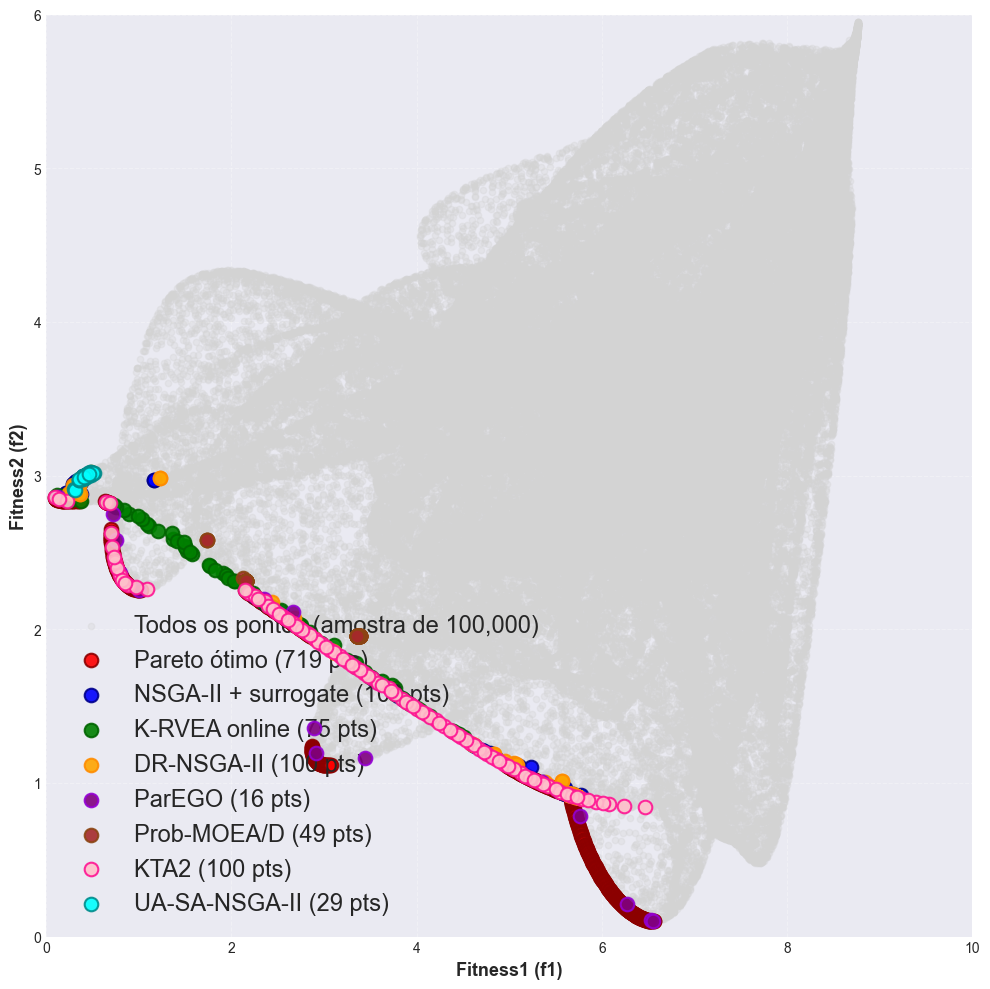

In [14]:
# Plota fronteira de Pareto real - com todos os baselines (MMF1)
fig_front = display_pareto_fronts3(df_bbob16, 
                                  [
                                    df_pareto_bbob16, 
                                    df_pareto_my2_bbob16, 
                                    df_pareto_krvea_bbob16,
                                    df_pareto_dr_bbob16,
                                    df_pareto_parego_bbob16,
                                    df_pareto_pmoead_bbob16,
                                    df_pareto_kta2_bbob16,
                                    df_pareto_ua_sa_bbob16
                                  ], 
                                   fitness1='f1', fitness2='f2', 
                                   front_names=[
                                    'Pareto ótimo', 
                                    'NSGA-II + surrogate',
                                    'K-RVEA online',
                                    'DR-NSGA-II', 
                                    'ParEGO',
                                    'Prob-MOEA/D',
                                    'KTA2',
                                    'UA-SA-NSGA-II'
                                    ], 
                                   sample_size=100_000)
#fig_front.savefig('data/figures/nb5_front_verdadeiro_mmf1_baselines.jpg', dpi=150, bbox_inches='tight')

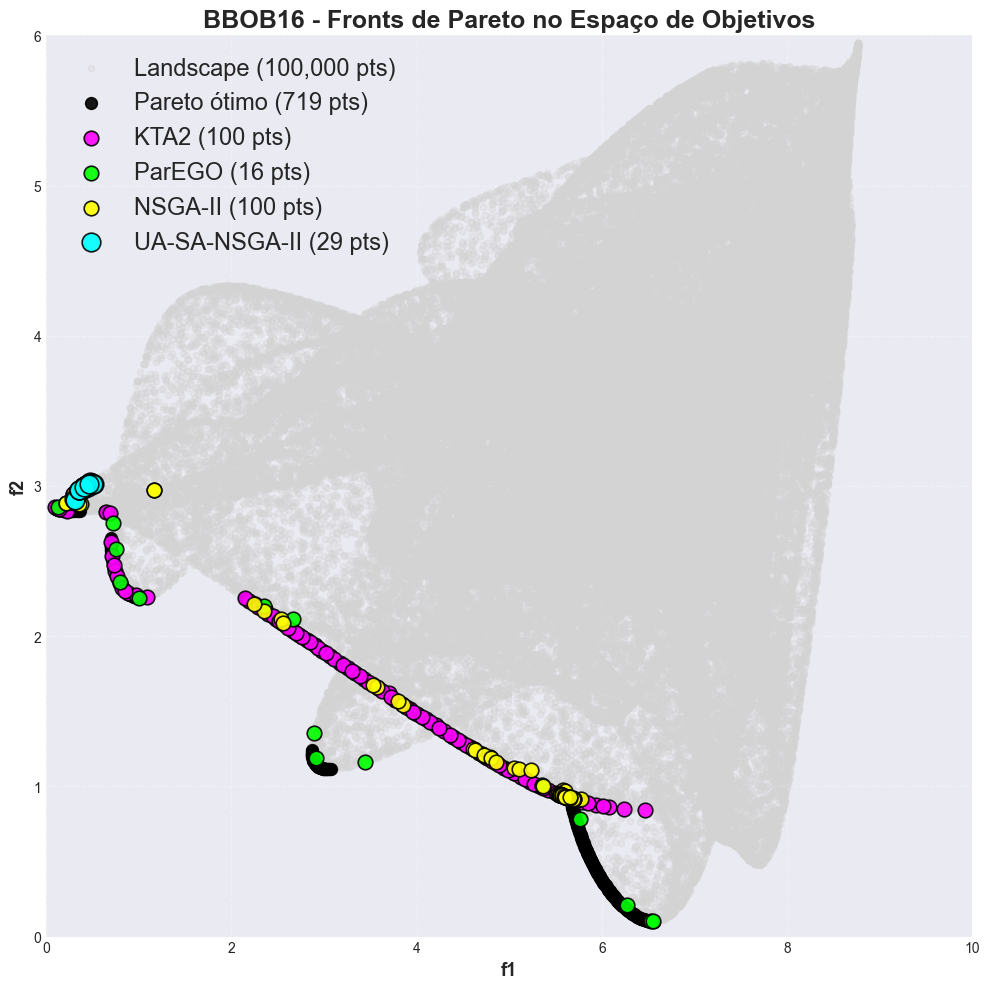

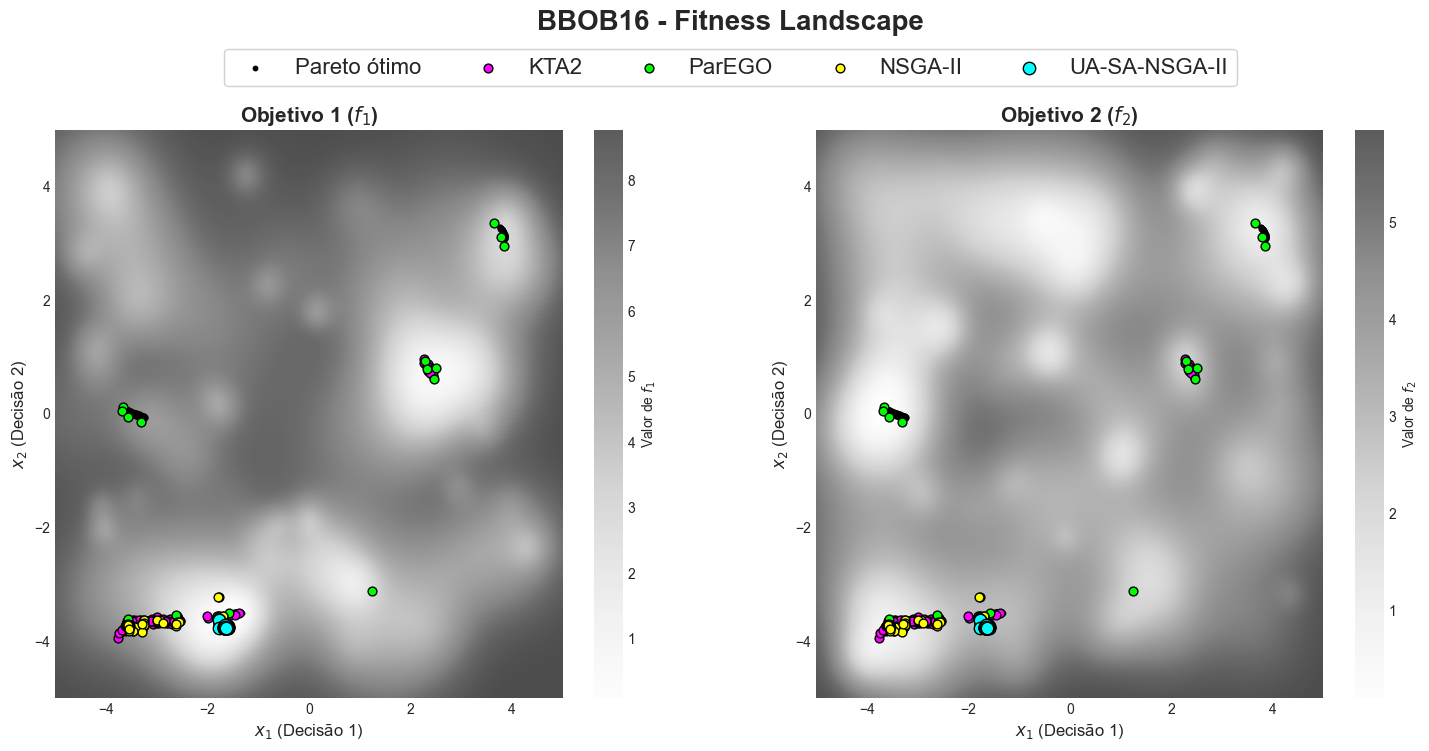

In [15]:
#https://matplotlib.org/stable/gallery/color/named_colors.html
#https://matplotlib.org/stable/gallery/color/colormap_reference.html

# Definir soluções em um dicionário
dict_solutions = {
    'Pareto ótimo':  [df_pareto_bbob16,        'black',    70],
    'KTA2':          [df_pareto_kta2_bbob16,   'fuchsia', 110],
    'ParEGO':        [df_pareto_parego_bbob16, 'lime',    110],
    'NSGA-II':       [df_pareto_my2_bbob16,    'yellow',  110],
    'UA-SA-NSGA-II': [df_pareto_ua_sa_bbob16,  'cyan',    180],
#    'K-RVEA':        [df_pareto_krvea_bbob16,  'cyan',   110],
#    'DR-NSGA-II':    [df_pareto_dr_bbob16,     'lime',   110],
#    'Prob-MOEA/D':   [df_pareto_pmoead_bbob16, 'green',  110],
}

# Usando os nomes de coluna do problema BBOB16
display_pareto_fronts7(
    df_bbob16,
    dict_solutions,
    fitness1='f1',
    fitness2='f2',
    sample_size=100_000,
    title='BBOB16 - Fronts de Pareto no Espaço de Objetivos'
)

# Ajustando tamanho dos pontos para segunda visualização
for i in dict_solutions:
    dict_solutions[i][2] = 40

dict_solutions['Pareto ótimo'][2]  = 10
dict_solutions['UA-SA-NSGA-II'][2] = 80


# Chamar a função
fig = plot_landscapes_heatmap_dashboard_v2(
    bbob16,
    df_bbob16,
    dict_solutions,
    cmap='Greys',
    cmap_lighten=0.3,
    title='BBOB16 - Fitness Landscape'
)

# MMF4

In [16]:
config['limite_inferior'] = np.array([-1, 0])
config['limite_superior'] = np.array([ 1, 2])

In [17]:
decision_variables = ['x_1', 'x_2']

df_landscape_mmf4 = create_landscape_from_predictions(
    df_previsao=df_mmf4_previsao,
    df_mcmc=df_mcmc_mmf4,
    decision_variables=decision_variables
)

print(df_landscape_mmf4.shape)
df_landscape_mmf4.head()

(999504, 10)


,x_1,x_2,f1,f2,f1_original,f2_original,f1_predicted,f2_predicted,fitness1,fitness2
0,-1.0,0.000000,0.992287,-0.224668,1.0,2.960407e-31,0.875836,0.564953,"[0.813, 0.914, 1.101, 0.725, 0.985, 1.008, 0.8...","[-0.118, 0.341, 1.598, 0.287, 1.847, 2.31, 0.8..."
1,-1.0,0.002002,0.931919,-0.229068,1.0,7.911394e-05,0.875836,0.564953,"[0.813, 0.914, 1.101, 0.725, 0.985, 1.008, 0.8...","[-0.118, 0.341, 1.598, 0.287, 1.847, 2.31, 0.8..."
2,-1.0,0.004004,1.182322,0.331255,1.0,3.164433e-04,0.875836,0.564953,"[0.813, 0.914, 1.101, 0.725, 0.985, 1.008, 0.8...","[-0.118, 0.341, 1.598, 0.287, 1.847, 2.31, 0.8..."
3,-1.0,0.006006,0.956288,0.370965,1.0,7.119504e-04,0.875836,0.564953,"[0.813, 0.914, 1.101, 0.725, 0.985, 1.008, 0.8...","[-0.118, 0.341, 1.598, 0.287, 1.847, 2.31, 0.8..."
4,-1.0,0.008008,0.926453,-0.308957,1.0,1.265573e-03,0.875836,0.564953,"[0.813, 0.914, 1.101, 0.725, 0.985, 1.008, 0.8...","[-0.118, 0.341, 1.598, 0.287, 1.847, 2.31, 0.8..."


In [18]:
#returns = run_algorithms(df_mmf4_previsao, df_landscape_mmf4, df_mcmc_mmf4, mmf4, dict_algorithms, config)
#
#df_pareto_my2_mmf4    = returns['NSGA2_surrogate']
#df_pareto_krvea_mmf4  = returns['K-RVEA']
#df_pareto_dr_mmf4     = returns['DR-NSGA-II']
#df_pareto_parego_mmf4 = returns['ParEGO']
#df_pareto_pmoead_mmf4 = returns['Prob-MOEA/D']
#df_pareto_kta2_mmf4   = returns['KTA2']
#df_pareto_ua_sa_mmf4  = returns['UA-SA-NSGA2']
#
#df_pareto_my2_mmf4.to_parquet('data/dataframes/MMF4/df_pareto_my2_mmf4.parquet')
#df_pareto_krvea_mmf4.to_parquet('data/dataframes/MMF4/df_pareto_krvea_mmf4.parquet')
#df_pareto_dr_mmf4.to_parquet('data/dataframes/MMF4/df_pareto_dr_mmf4.parquet')
#df_pareto_parego_mmf4.to_parquet('data/dataframes/MMF4/df_pareto_parego_mmf4.parquet')
#df_pareto_pmoead_mmf4.to_parquet('data/dataframes/MMF4/df_pareto_pmoead_mmf4.parquet')
#df_pareto_kta2_mmf4.to_parquet('data/dataframes/MMF4/df_pareto_kta2_mmf4.parquet')
#df_pareto_ua_sa_mmf4.to_parquet('data/dataframes/MMF4/df_pareto_ua_sa_mmf4.parquet')

In [19]:
df_pareto_my2_mmf4    = pd.read_parquet('data/dataframes/MMF4/df_pareto_my2_mmf4.parquet')
df_pareto_krvea_mmf4  = pd.read_parquet('data/dataframes/MMF4/df_pareto_krvea_mmf4.parquet')
df_pareto_dr_mmf4     = pd.read_parquet('data/dataframes/MMF4/df_pareto_dr_mmf4.parquet')
df_pareto_parego_mmf4 = pd.read_parquet('data/dataframes/MMF4/df_pareto_parego_mmf4.parquet')
df_pareto_pmoead_mmf4 = pd.read_parquet('data/dataframes/MMF4/df_pareto_pmoead_mmf4.parquet')
df_pareto_kta2_mmf4   = pd.read_parquet('data/dataframes/MMF4/df_pareto_kta2_mmf4.parquet')
df_pareto_ua_sa_mmf4  = pd.read_parquet('data/dataframes/MMF4/df_pareto_ua_sa_mmf4.parquet')

print("============== Resultados por algoritmo (BBOB16) ==============\n")
#print(f"NSGA-II original:       {len(df_pareto_my)} soluções")
print(f"NSGA-II + surrogate:    {len(df_pareto_my2_mmf4)} soluções")
print(f"K-RVEA online:          {len(df_pareto_krvea_mmf4)} soluções")
print(f"DR-NSGA-II:             {len(df_pareto_dr_mmf4)} soluções")
print(f"ParEGO:                 {len(df_pareto_parego_mmf4)} soluções")
print(f"Prob-MOEA/D:            {len(df_pareto_pmoead_mmf4)} soluções")
print(f"KTA2:                   {len(df_pareto_kta2_mmf4)} soluções")
print(f"UA-SA-NSGA-II:          {len(df_pareto_ua_sa_mmf4)} soluções")

df_pareto_mmf4 = find_pareto_front(df_mmf4, minimize=True, fitness1='f1', fitness2='f2')

============== Resultados por algoritmo (BBOB16) ==============

NSGA-II + surrogate:    100 soluções
K-RVEA online:          81 soluções
DR-NSGA-II:             100 soluções
ParEGO:                 34 soluções
Prob-MOEA/D:            70 soluções
KTA2:                   100 soluções
UA-SA-NSGA-II:          1 soluções
Encontrando fronteira de Pareto (algoritmo otimizado)...
Total de pontos no espaço de busca: 1,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 1,019 pontos.
Isso representa 0.1019% do espaço de busca.


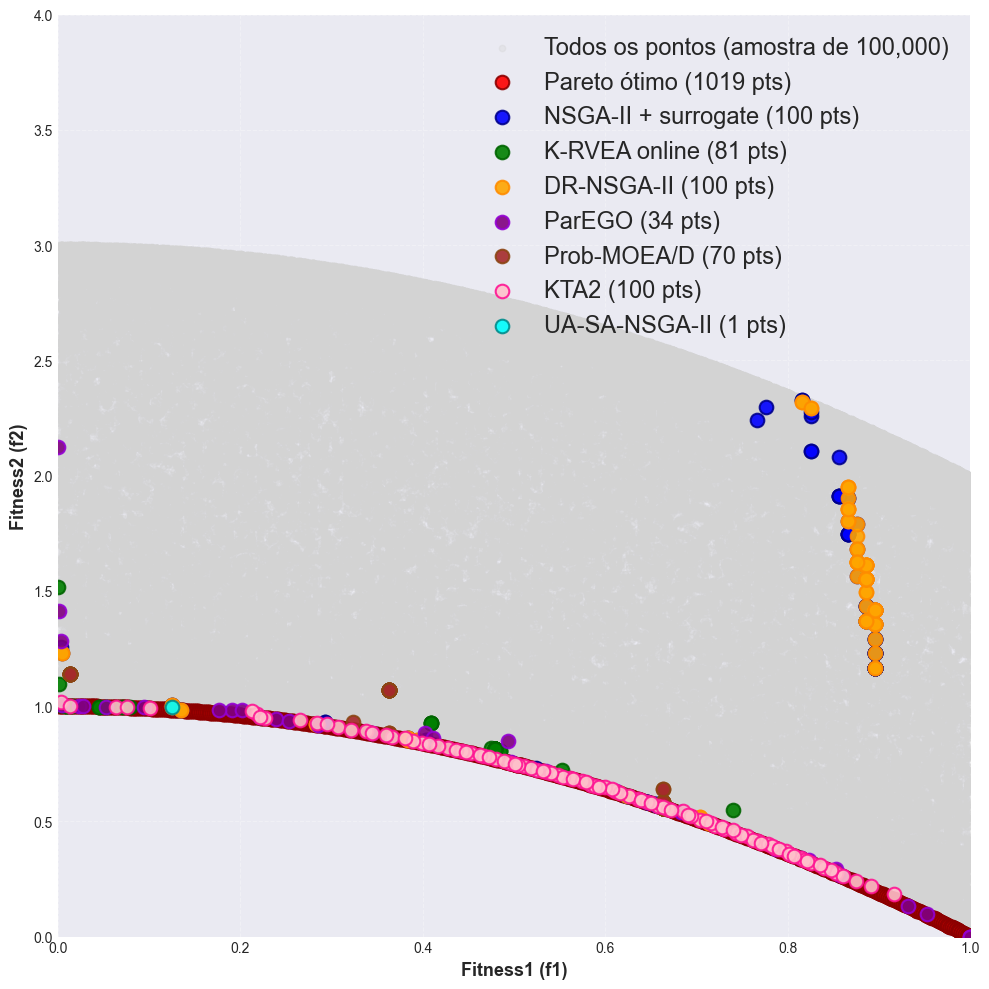

In [20]:
# Plota fronteira de Pareto real - com todos os baselines (MMF1)
fig_front = display_pareto_fronts3(df_mmf4, 
                                  [
                                    df_pareto_mmf4, 
                                    df_pareto_my2_mmf4, 
                                    df_pareto_krvea_mmf4,
                                    df_pareto_dr_mmf4, 
                                    df_pareto_parego_mmf4,
                                    df_pareto_pmoead_mmf4,
                                    df_pareto_kta2_mmf4,
                                    df_pareto_ua_sa_mmf4
                                  ], 
                                   fitness1='f1', fitness2='f2', 
                                   front_names=[
                                    'Pareto ótimo', 
                                    'NSGA-II + surrogate',
                                    'K-RVEA online',
                                    'DR-NSGA-II', 
                                    'ParEGO',
                                    'Prob-MOEA/D',
                                    'KTA2',
                                    'UA-SA-NSGA-II'
                                    ], 
                                   sample_size=100_000)
#fig_front.savefig('data/figures/nb5_front_verdadeiro_mmf1_baselines.jpg', dpi=150, bbox_inches='tight')

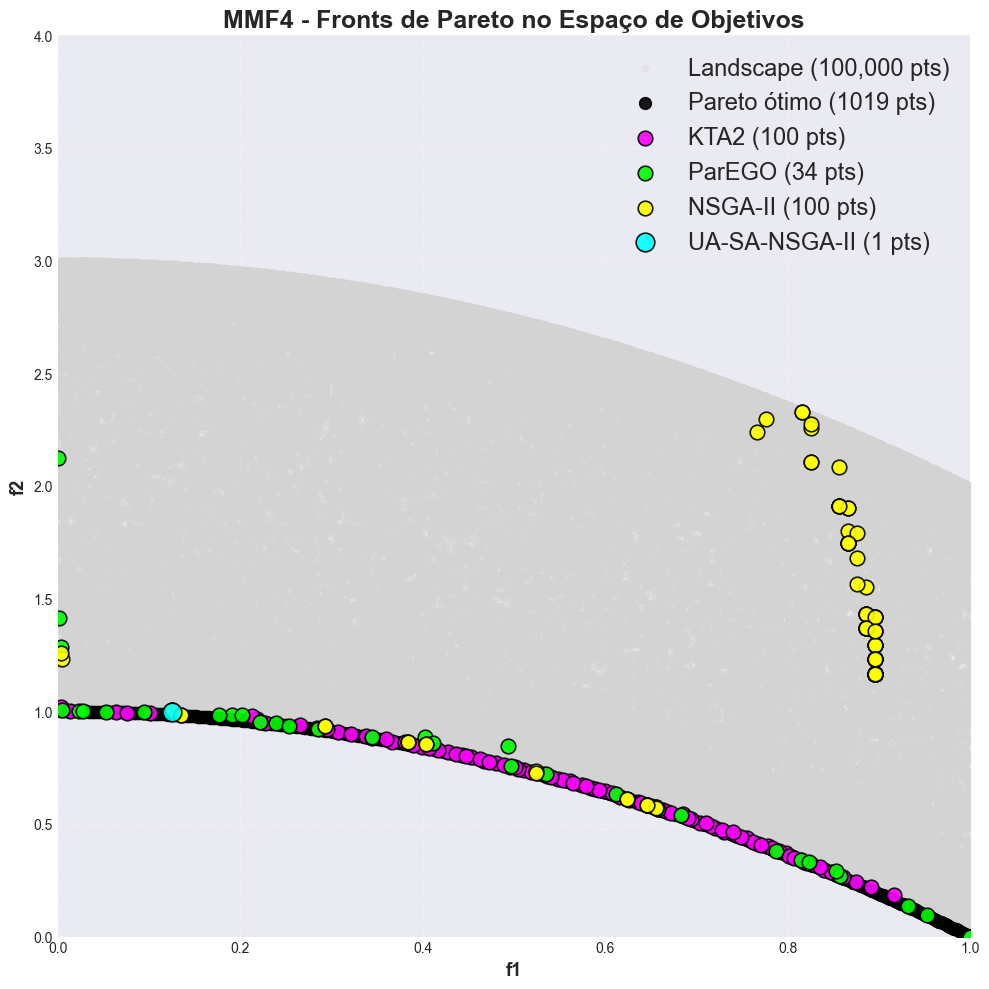

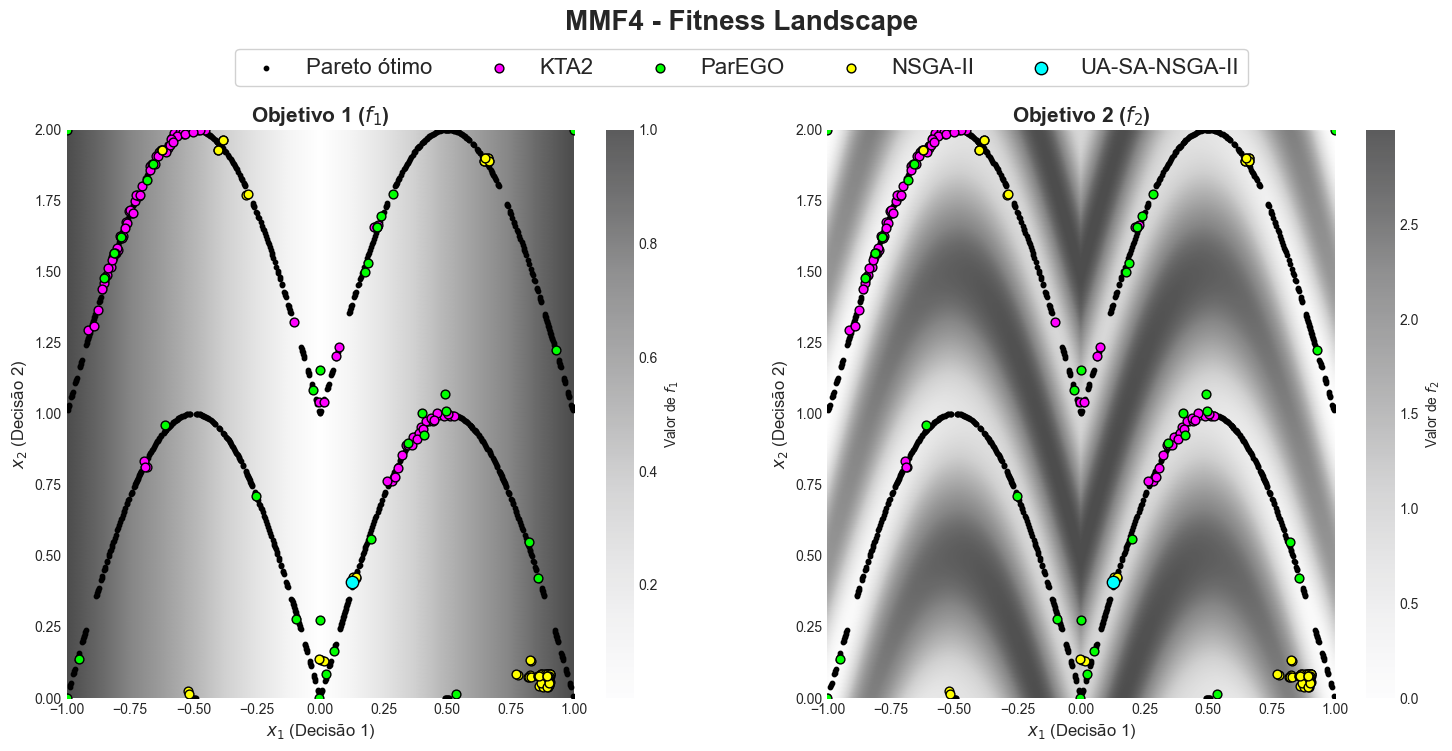

In [21]:
#https://matplotlib.org/stable/gallery/color/named_colors.html
#https://matplotlib.org/stable/gallery/color/colormap_reference.html

# Definir soluções em um dicionário
dict_solutions = {
    'Pareto ótimo':  [df_pareto_mmf4,        'black',    70],
    'KTA2':          [df_pareto_kta2_mmf4,   'fuchsia', 110],
    'ParEGO':        [df_pareto_parego_mmf4, 'lime',    110],
    'NSGA-II':       [df_pareto_my2_mmf4,    'yellow',  110],
    'UA-SA-NSGA-II': [df_pareto_ua_sa_mmf4,  'cyan' ,   180],
#    'K-RVEA':        [df_pareto_krvea_mmf4,  'cyan',   110],
#    'DR-NSGA-II':    [df_pareto_dr_mmf4,     'lime',   110],
#    'Prob-MOEA/D':   [df_pareto_pmoead_mmf4, 'green',  110],
}


# Usando os nomes de coluna do problema BBOB16
display_pareto_fronts7(
    df_mmf4,
    dict_solutions,
    fitness1='f1',
    fitness2='f2',
    sample_size=100_000,
    title='MMF4 - Fronts de Pareto no Espaço de Objetivos'
)

# Ajustando tamanho dos pontos para segunda visualização
for i in dict_solutions:
    dict_solutions[i][2] = 40

dict_solutions['Pareto ótimo'][2]  = 10
dict_solutions['UA-SA-NSGA-II'][2] = 80

# Chamar a função
fig = plot_landscapes_heatmap_dashboard_v2(
    mmf4,
    df_mmf4,
    dict_solutions,
    cmap='Greys',
    cmap_lighten=0.3,
    title='MMF4 - Fitness Landscape'
)

# MMF1

In [22]:
config['limite_inferior'] = np.array([1, -1])
config['limite_superior'] = np.array([3,  1])

In [23]:
decision_variables = ['x_1', 'x_2']

df_landscape_mmf1 = create_landscape_from_predictions(
    df_previsao=df_mmf1_previsao,
    df_mcmc=df_mcmc_mmf1,
    decision_variables=decision_variables
)

print(df_landscape_mmf1.shape)
df_landscape_mmf1.head()

(999504, 10)


,x_1,x_2,f1,f2,f1_original,f2_original,f1_predicted,f2_predicted,fitness1,fitness2
0,1.0,-1.000000,0.992287,1.730255,1.0,2.000000,0.875836,2.484513,"[0.778, 0.862, 1.018, 0.728, 1.138, 1.087, 0.8...","[4.255, 4.863, 4.37, 2.033, 4.855, 6.498, 3.34..."
1,1.0,-0.997998,0.931919,1.716878,1.0,1.992000,0.875836,2.484513,"[0.778, 0.862, 1.018, 0.728, 1.138, 1.087, 0.8...","[4.255, 4.863, 4.37, 2.033, 4.855, 6.498, 3.34..."
2,1.0,-0.995996,1.182322,2.381354,1.0,1.984016,0.875836,2.484513,"[0.778, 0.862, 1.018, 0.728, 1.138, 1.087, 0.8...","[4.255, 4.863, 4.37, 2.033, 4.855, 6.498, 3.34..."
3,1.0,-0.993994,0.956288,2.420588,1.0,1.976048,0.875836,2.484513,"[0.778, 0.862, 1.018, 0.728, 1.138, 1.087, 0.8...","[4.255, 4.863, 4.37, 2.033, 4.855, 6.498, 3.34..."
4,1.0,-0.991992,0.926453,1.595631,1.0,1.968096,0.875836,2.484513,"[0.778, 0.862, 1.018, 0.728, 1.138, 1.087, 0.8...","[4.255, 4.863, 4.37, 2.033, 4.855, 6.498, 3.34..."


In [24]:
#returns = run_algorithms(df_mmf1_previsao, df_landscape_mmf1, df_mcmc_mmf1, mmf1, dict_algorithms, config)
#
#df_pareto_my2_mmf1    = returns['NSGA2_surrogate']
#df_pareto_krvea_mmf1  = returns['K-RVEA']
#df_pareto_dr_mmf1     = returns['DR-NSGA-II']
#df_pareto_parego_mmf1 = returns['ParEGO']
#df_pareto_pmoead_mmf1 = returns['Prob-MOEA/D']
#df_pareto_kta2_mmf1   = returns['KTA2']
#df_pareto_ua_sa_mmf1  = returns['UA-SA-NSGA2']
#
#df_pareto_my2_mmf1.to_parquet('data/dataframes/MMF1/df_pareto_my2_mmf1.parquet')
#df_pareto_krvea_mmf1.to_parquet('data/dataframes/MMF1/df_pareto_krvea_mmf1.parquet')
#df_pareto_dr_mmf1.to_parquet('data/dataframes/MMF1/df_pareto_dr_mmf1.parquet')
#df_pareto_parego_mmf1.to_parquet('data/dataframes/MMF1/df_pareto_parego_mmf1.parquet')
#df_pareto_pmoead_mmf1.to_parquet('data/dataframes/MMF1/df_pareto_pmoead_mmf1.parquet')
#df_pareto_kta2_mmf1.to_parquet('data/dataframes/MMF1/df_pareto_kta2_mmf1.parquet')
#df_pareto_ua_sa_mmf1.to_parquet('data/dataframes/MMF1/df_pareto_ua_sa_mmf1.parquet')

In [25]:
df_pareto_my2_mmf1    = pd.read_parquet('data/dataframes/MMF1/df_pareto_my2_mmf1.parquet')
df_pareto_krvea_mmf1  = pd.read_parquet('data/dataframes/MMF1/df_pareto_krvea_mmf1.parquet')
df_pareto_dr_mmf1     = pd.read_parquet('data/dataframes/MMF1/df_pareto_dr_mmf1.parquet')
df_pareto_parego_mmf1 = pd.read_parquet('data/dataframes/MMF1/df_pareto_parego_mmf1.parquet')
df_pareto_pmoead_mmf1 = pd.read_parquet('data/dataframes/MMF1/df_pareto_pmoead_mmf1.parquet')
df_pareto_kta2_mmf1   = pd.read_parquet('data/dataframes/MMF1/df_pareto_kta2_mmf1.parquet')
df_pareto_ua_sa_mmf1  = pd.read_parquet('data/dataframes/MMF1/df_pareto_ua_sa_mmf1.parquet')



print("============== Resultados por algoritmo (BBOB16) ==============\n")
print(f"NSGA-II + surrogate:    {len(df_pareto_my2_mmf1)} soluções")
print(f"K-RVEA online:          {len(df_pareto_krvea_mmf1)} soluções")
print(f"DR-NSGA-II:             {len(df_pareto_dr_mmf1)} soluções")
print(f"ParEGO:                 {len(df_pareto_parego_mmf1)} soluções")
print(f"Prob-MOEA/D:            {len(df_pareto_pmoead_mmf1)} soluções")
print(f"KTA2:                   {len(df_pareto_kta2_mmf1)} soluções")
print(f"UA-SA-NSGA-II:          {len(df_pareto_ua_sa_mmf1)} soluções")

df_pareto_mmf1 = find_pareto_front(df_mmf1, minimize=True, fitness1='f1', fitness2='f2')

============== Resultados por algoritmo (BBOB16) ==============

NSGA-II + surrogate:    100 soluções
K-RVEA online:          49 soluções
DR-NSGA-II:             100 soluções
ParEGO:                 33 soluções
Prob-MOEA/D:            42 soluções
KTA2:                   80 soluções
UA-SA-NSGA-II:          10 soluções
Encontrando fronteira de Pareto (algoritmo otimizado)...
Total de pontos no espaço de busca: 1,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 1,000 pontos.
Isso representa 0.1000% do espaço de busca.


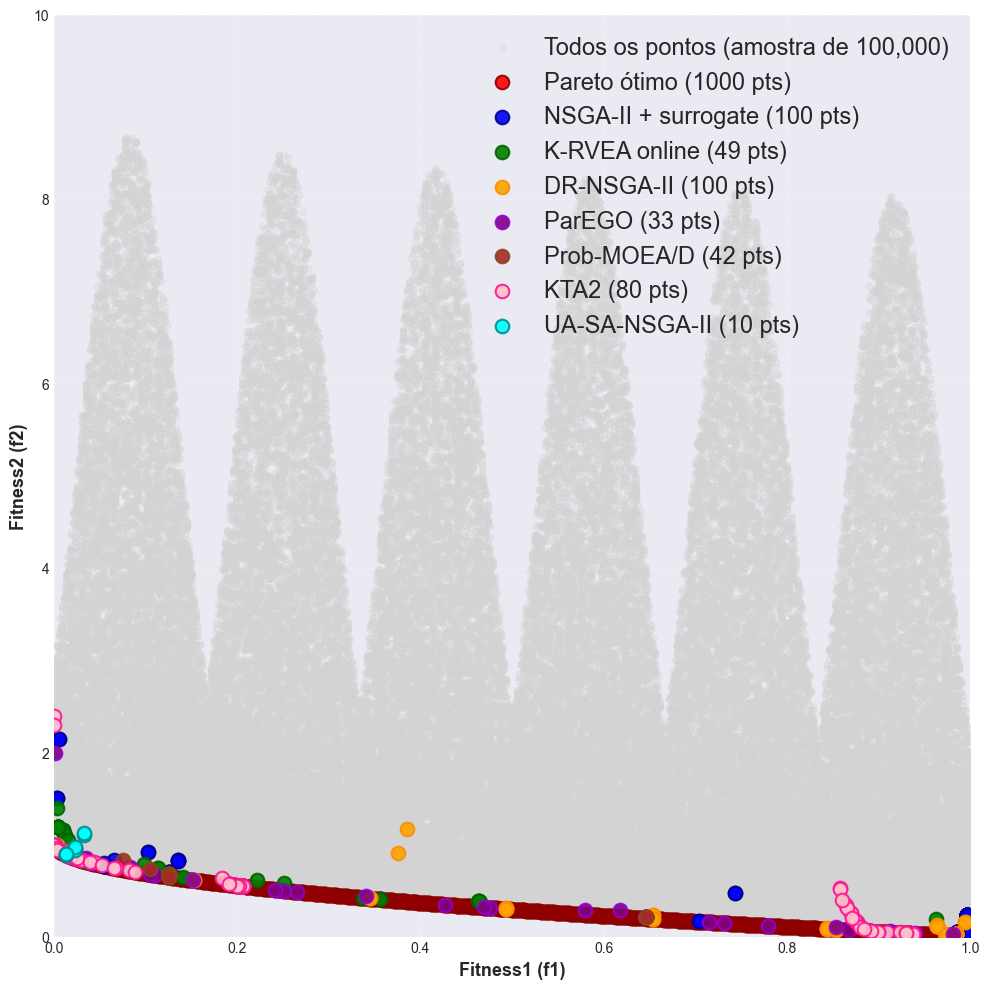

In [26]:
# Plota fronteira de Pareto real - com todos os baselines (MMF1)
fig_front = display_pareto_fronts3(df_mmf1, 
                                  [
                                    df_pareto_mmf1, 
                                    df_pareto_my2_mmf1, 
                                    df_pareto_krvea_mmf1,
                                    df_pareto_dr_mmf1, 
                                    df_pareto_parego_mmf1,
                                    df_pareto_pmoead_mmf1,
                                    df_pareto_kta2_mmf1,
                                    df_pareto_ua_sa_mmf1
                                  ], 
                                   fitness1='f1', fitness2='f2', 
                                   front_names=[
                                    'Pareto ótimo', 
                                    'NSGA-II + surrogate',
                                    'K-RVEA online',
                                    'DR-NSGA-II', 
                                    'ParEGO',
                                    'Prob-MOEA/D',
                                    'KTA2',
                                    'UA-SA-NSGA-II'
                                    ], 
                                   sample_size=100_000)
#fig_front.savefig('data/figures/nb5_front_verdadeiro_mmf1_baselines.jpg', dpi=150, bbox_inches='tight')

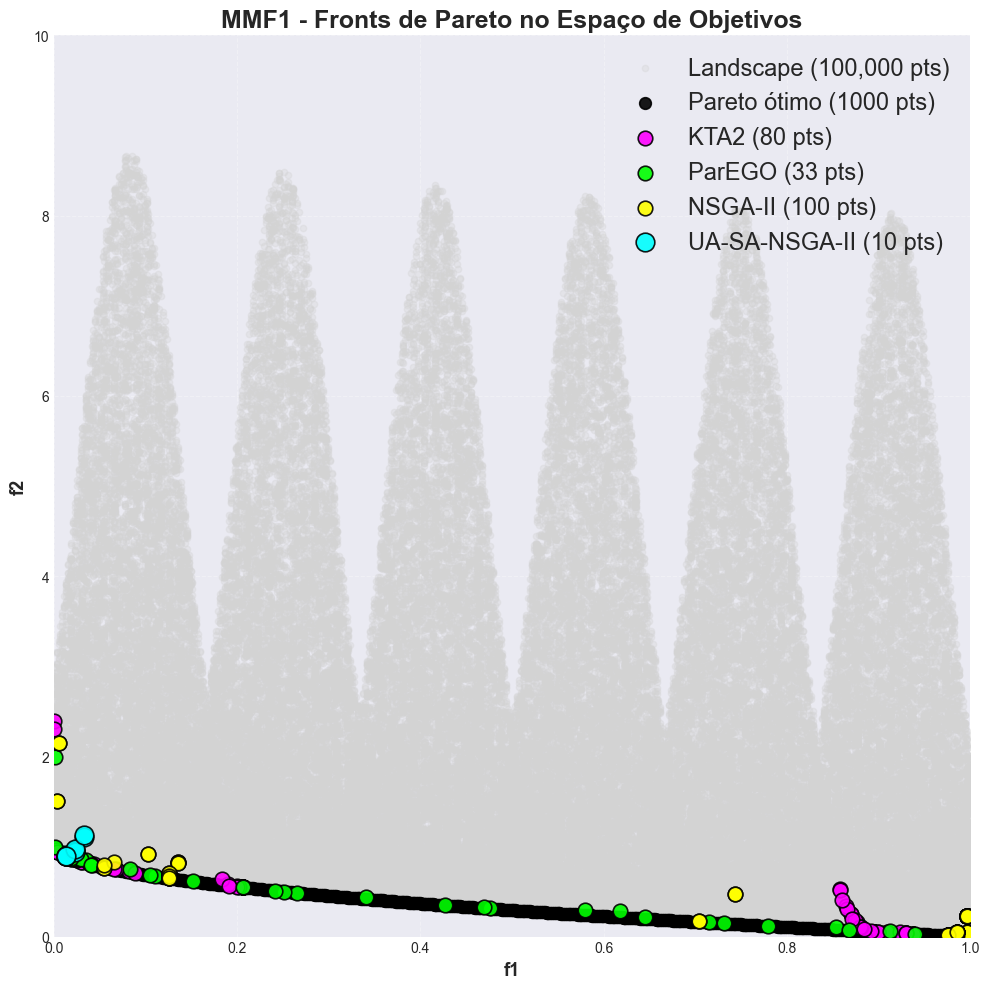

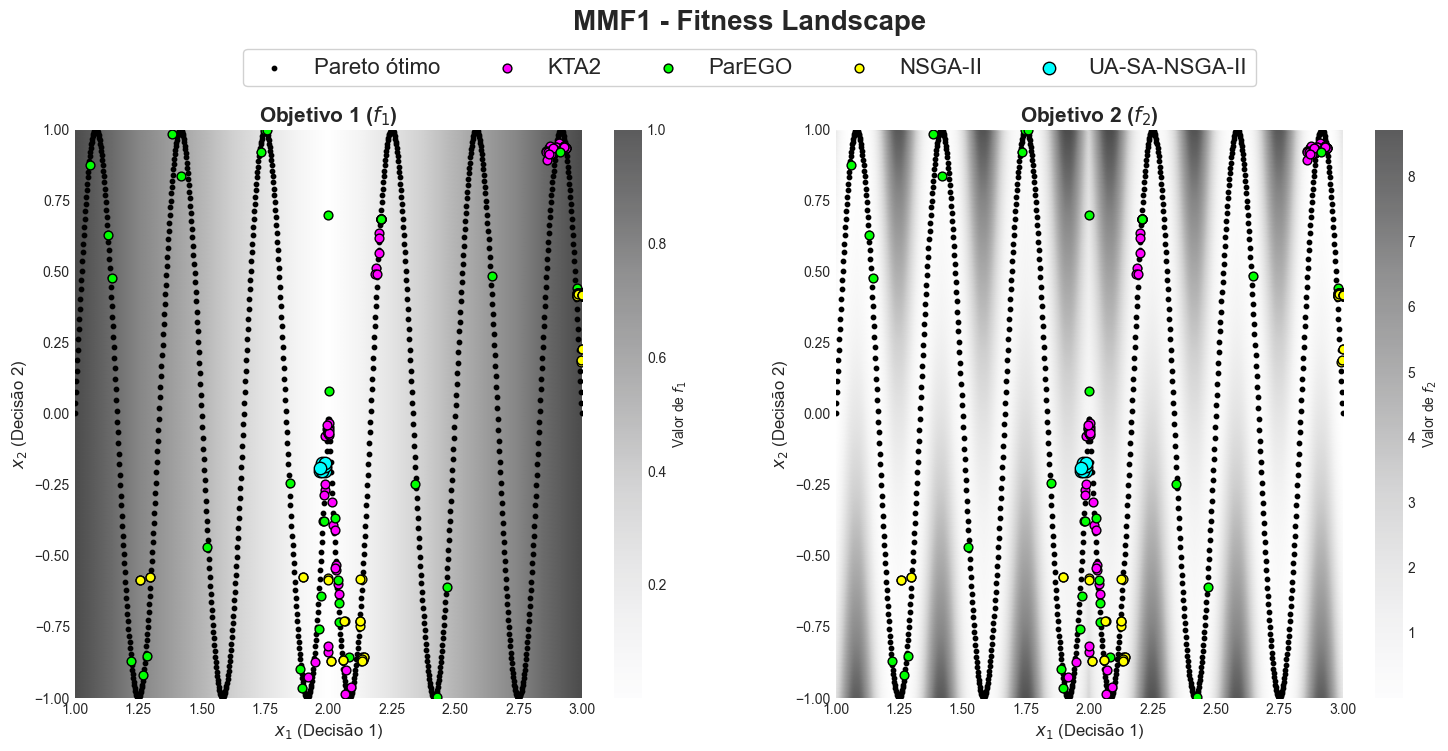

In [27]:
#https://matplotlib.org/stable/gallery/color/named_colors.html
#https://matplotlib.org/stable/gallery/color/colormap_reference.html

# Definir soluções em um dicionário
dict_solutions = {
    'Pareto ótimo':  [df_pareto_mmf1,        'black',    70],
    'KTA2':          [df_pareto_kta2_mmf1,   'fuchsia', 110],
    'ParEGO':        [df_pareto_parego_mmf1, 'lime',    110],
    'NSGA-II':       [df_pareto_my2_mmf1,    'yellow',  110],
    'UA-SA-NSGA-II': [df_pareto_ua_sa_mmf1,  'cyan' ,   180],
#    'K-RVEA':        [df_pareto_krvea_mmf1,  'cyan',   110],
#    'DR-NSGA-II':    [df_pareto_dr_mmf1,     'lime',   110],
#    'Prob-MOEA/D':   [df_pareto_pmoead_mmf1, 'green',  110],
}


# Usando os nomes de coluna do problema BBOB16
display_pareto_fronts7(
    df_mmf1,
    dict_solutions,
    fitness1='f1',
    fitness2='f2',
    sample_size=100_000,
    title='MMF1 - Fronts de Pareto no Espaço de Objetivos'
)

# Ajustando tamanho dos pontos para segunda visualização
for i in dict_solutions:
    dict_solutions[i][2] = 40

dict_solutions['Pareto ótimo'][2]  = 10
dict_solutions['UA-SA-NSGA-II'][2] = 80

# Chamar a função
fig = plot_landscapes_heatmap_dashboard_v2(
    mmf1,
    df_mmf1,
    dict_solutions,
    cmap='Greys',
    cmap_lighten=0.3,
    title='MMF1 - Fitness Landscape'
)

# Later

#### processamento original + gifs

In [28]:
#df_pareto_real = find_pareto_front(df_bbob16, minimize=True, fitness1='f1', fitness2='f2')
#
#df_pareto_real = df[df.registro.isin(df_pareto_real.registro.unique())]
##df_pareto_my = df[df.registro.isin(df_pareto_my.registro.unique())]
#df_pareto_ua_sa = df[df.registro.isin(df_pareto_ua_sa.registro.unique())]
##df_pareto_ua_sa_p40 = df[df.registro.isin(df_pareto_ua_sa_p40.registro.unique())]
##df_pareto_ua_sa_ds_niching = df[df.registro.isin(df_pareto_ua_sa_ds_niching.registro.unique())]
#
## convergencia entre resultados
#fig = display_pareto_fronts3(df, [df_pareto_real, df_pareto_my, df_pareto_ua_sa],#, df_pareto_ua_sa_p40],
#                       front_names=['Pareto Real', 'NSGA-II', 'UA-SA-NSGA-II'], sample_size=1000000,
#                       front_colors=['red', 'blue', 'orange'])
#fig.savefig('data/figures/nb5_pareto_ua_saea_problema1.jpg', dpi=150, bbox_inches='tight')
#
#fig_landscape_p1 = display_fitness_landscape_with_paretos(df, [df_pareto_real, df_pareto_my, df_pareto_ua_sa], 
#                                                          front_colors=['red', 'blue', 'orange'], 
#                                                          n_regioes=5, show_error_subplot=True)
#fig_landscape_p1.savefig('data/figures/nb5_landscape_ua_saea_problema1.jpg', dpi=150, bbox_inches='tight')
#
#print('===================== UA-SA-NSGA-II =====================')
#gamma_results = calculate_gamma_convergence_metric(df, df_pareto_real, df_pareto_ua_sa)
#print_gamma_metric(gamma_results)
#
#fitness_sum_results = calculate_fitness_sum_statistics(df, df_pareto_ua_sa)
#print_fitness_sum_statistics(fitness_sum_results)
#
#delta_results = calculate_delta_diversity_metric(df, df_pareto_real, df_pareto_ua_sa)
#print_delta_metric(delta_results)
#
##print('===================== gamma ua-sa-nsga2 (percentil 40) =====================')
##gamma_results = calculate_gamma_convergence_metric(df, df_pareto_real, df_pareto_ua_sa_p40)
##print_gamma_metric(gamma_results)
#
##print('===================== gamma ua-sa-nsga2 com niching =====================')
##gamma_results = calculate_gamma_convergence_metric(df, df_pareto_real, df_pareto_ua_sa_ds_niching)
##print_gamma_metric(gamma_results)
#
#print('\n===================== NSGA-II =====================')
#gamma_results = calculate_gamma_convergence_metric(df, df_pareto_real, df_pareto_my)
#print_gamma_metric(gamma_results)
#
#fitness_sum_results = calculate_fitness_sum_statistics(df, df_pareto_my)
#print_fitness_sum_statistics(fitness_sum_results)
#
#delta_results = calculate_delta_diversity_metric(df, df_pareto_real, df_pareto_my)
#print_delta_metric(delta_results)

In [29]:
#if salva_gifs:
#    # Gerar GIF com a evolução das populações
#    caminho_gif = gerar_gif_evolucao_nsga2(
#        df_landscape=df,  # Mesmo dataframe usado acima
#        history=history,
#        nome_arquivo='gif_pareto_p1.gif',
#        fps=5,  # Ajuste a velocidade conforme preferir
#        output_dir='data/gifs'
#    )
#
#    print(f"GIF salvo em: {caminho_gif}")


#    # Gerar GIF com a evolução das populações
#    caminho_gif = gerar_gif_evolucao_nsga2(
#        df_landscape=df,  # Mesmo dataframe usado acima
#        history=history_niching,
#        nome_arquivo='gif_pareto_p1_ds_niching.gif',
#        fps=5,  # Ajuste a velocidade conforme preferir
#        output_dir='data/gifs'
#    )
#
#    print(f"GIF salvo em: {caminho_gif}")

In [30]:
#df_history = history_to_dataframe(history).drop(columns=['id_solucao'])
#df_history = df_history.sort_values(by=['geracao','genotipo'])
#df_history['id_solucao'] = df_history.groupby(['geracao']).cumcount() + 1
#display_evolution_of_genotypes(df_history)
#  
#df_history = history_to_dataframe(history_niching).drop(columns=['id_solucao'])
#df_history = df_history.sort_values(by=['geracao','genotipo'])
#df_history['id_solucao'] = df_history.groupby(['geracao']).cumcount() + 1
#display_evolution_of_genotypes(df_history)

#### melhores solucoes

In [31]:
#df_pareto_my, _, _, _  = run_my_nsga2(config, df_predicted)
#
#config['n_generations'] = 40
#config['utiliza_ds_niching'] = False
#df_pareto_ua_sa, history = run_my_uasa_nsga2(config, df_landscape1, save_history=True)

#config['n_generations'] = 56
#config['utiliza_ds_niching'] = True
#df_pareto_ua_sa_ds_niching, history_niching = run_my_uasa_nsga2(config, df_landscape1, save_history=True)

In [32]:
#df_pareto_real = find_pareto_front(df)
#
#df_pareto_real = df[df.registro.isin(df_pareto_real.registro.unique())]
#df_pareto_my = df[df.registro.isin(df_pareto_my.registro.unique())]
#df_pareto_ua_sa = df[df.registro.isin(df_pareto_ua_sa.registro.unique())]
##df_pareto_ua_sa_ds_niching = df[df.registro.isin(df_pareto_ua_sa_ds_niching.registro.unique())]
#
## convergencia entre resultados
#fig = display_pareto_fronts3(df, [df_pareto_real, df_pareto_my, df_pareto_ua_sa],#, df_pareto_ua_sa_ds_niching], 
#                       front_names=['Pareto Real', 'NSGA-II', 'UA-SA-NSGA-II'], sample_size=1000000,
#                       front_colors=['red', 'blue', 'orange'])
#fig.savefig('data/figures/nb5_pareto_best_ua_saea_problema1.jpg', dpi=150, bbox_inches='tight')
#
#fig_landscape_p1_best = display_fitness_landscape_with_paretos(df, [df_pareto_real, df_pareto_my, df_pareto_ua_sa], 
#                                                               front_colors=['red', 'blue', 'orange'], 
#                                                               n_regioes=5, show_error_subplot=True)
#fig_landscape_p1_best.savefig('data/figures/nb5_landscape_best_ua_saea_problema1.jpg', dpi=150, bbox_inches='tight')
#
#print('===================== UA-SA-NSGA-II =====================')
#gamma_results = calculate_gamma_convergence_metric(df, df_pareto_real, df_pareto_ua_sa)
#print_gamma_metric(gamma_results)
#
#fitness_sum_results = calculate_fitness_sum_statistics(df, df_pareto_ua_sa)
#print_fitness_sum_statistics(fitness_sum_results)
#
#delta_results = calculate_delta_diversity_metric(df, df_pareto_real, df_pareto_ua_sa)
#print_delta_metric(delta_results)
#
##print('===================== gamma ua-sa-nsga2 com niching =====================')
##gamma_results = calculate_gamma_convergence_metric(df, df_pareto_real, df_pareto_ua_sa_ds_niching)
##print_gamma_metric(gamma_results)
#
#print('\n===================== NSGA-II =====================')
#gamma_results = calculate_gamma_convergence_metric(df, df_pareto_real, df_pareto_my)
#print_gamma_metric(gamma_results)
#
#fitness_sum_results = calculate_fitness_sum_statistics(df, df_pareto_my)
#print_fitness_sum_statistics(fitness_sum_results)
#
#delta_results = calculate_delta_diversity_metric(df, df_pareto_real, df_pareto_my)
#print_delta_metric(delta_results)

#### Landscape Previsto

In [33]:
#df_pareto_real = find_pareto_front(df_predicted)
#
#df_pareto_real = df_predicted[df_predicted.registro.isin(df_pareto_real.registro.unique())]
#df_pareto_my = df_predicted[df_predicted.registro.isin(df_pareto_my.registro.unique())]
#df_pareto_ua_sa = df_predicted[df_predicted.registro.isin(df_pareto_ua_sa.registro.unique())]
##df_pareto_ua_sa_ds_niching = df_predicted[df_predicted.registro.isin(df_pareto_ua_sa_ds_niching.registro.unique())]
#
## convergencia entre resultados
#fig = display_pareto_fronts3(df_predicted, [df_pareto_real, df_pareto_my, df_pareto_ua_sa],#, df_pareto_ua_sa_ds_niching],
#                       front_names=['Pareto Surrogate', 'NSGA-II', 'UA-SA-NSGA-II'], sample_size=1000000,
#                       front_colors=['red', 'blue', 'orange'])
#
#
#print('===================== UA-SA-NSGA-II =====================')
#gamma_results = calculate_gamma_convergence_metric(df_predicted, df_pareto_real, df_pareto_ua_sa)
#print_gamma_metric(gamma_results)
#
#fitness_sum_results = calculate_fitness_sum_statistics(df_predicted, df_pareto_ua_sa)
#print_fitness_sum_statistics(fitness_sum_results)
#
#delta_results = calculate_delta_diversity_metric(df_predicted, df_pareto_real, df_pareto_ua_sa)
#print_delta_metric(delta_results)
#
#print('\n===================== NSGA-II =====================')
#gamma_results = calculate_gamma_convergence_metric(df_predicted, df_pareto_real, df_pareto_my)
#print_gamma_metric(gamma_results)
#
#fitness_sum_results = calculate_fitness_sum_statistics(df_predicted, df_pareto_my)
#print_fitness_sum_statistics(fitness_sum_results)
#
#delta_results = calculate_delta_diversity_metric(df_predicted, df_pareto_real, df_pareto_my)
#print_delta_metric(delta_results)